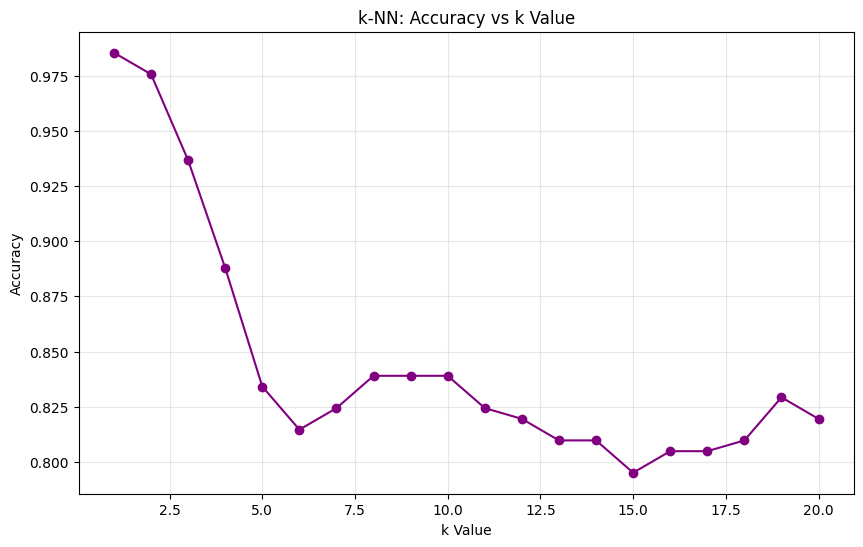

✅ Best k value: 1
✅ Best accuracy: 0.9854

📊 k-NN Final Accuracy: 0.9854


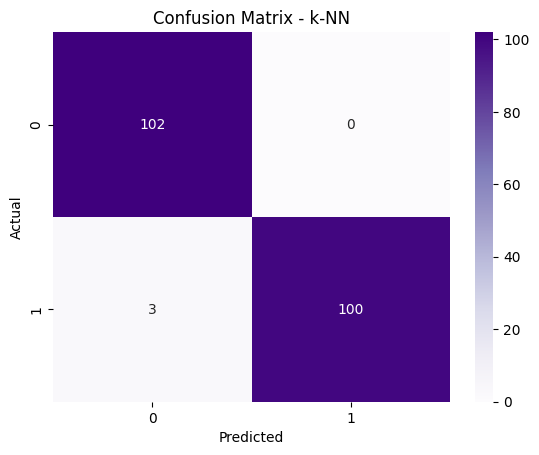

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [2]:
"""
Assignment II: k-Nearest Neighbors (k-NN) for Heart Disease Prediction
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load data
df = pd.read_csv('heart.csv')
X = df.drop('target', axis=1)
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Find best k value
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='purple')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('k-NN: Accuracy vs k Value')
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_values.png')
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"✅ Best k value: {best_k}")
print(f"✅ Best accuracy: {best_accuracy:.4f}")

# Train with best k
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Final evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 k-NN Final Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - k-NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('knn_cm.png')
plt.show()

print(classification_report(y_test, y_pred))